In [1]:
def _kf_apply_doc_styles() -> None:
    from pathlib import Path
    import kfactory.utilities
    import kfactory.widgets.interactive

    _lyp = Path('/home/runner/work/kfactory/kfactory/docs/source-built/_static/doc_styles.lyp')
    if not _lyp.is_file():
        return
    _original = kfactory.utilities.as_png_data

    def _styled_as_png_data(c, layer_properties=None, **kwargs):
        return _original(c, layer_properties=layer_properties or str(_lyp), **kwargs)

    kfactory.utilities.as_png_data = _styled_as_png_data
    kfactory.widgets.interactive.as_png_data = _styled_as_png_data


_kf_apply_doc_styles()


# Straight Waveguide

`straight_dbu_factory(kcl)` returns a cached cell function. Its canonical input
is a **cross section** (by name, instance, or spec dict); the `length` is in
**DBU** (database units). Convert µm values with `kcl.to_dbu()`.

In [2]:
import kfactory as kf
from kfactory.factories.straight import straight_dbu_factory


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGCLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)


pdk = kf.KCLayout("FACTORIES_STRAIGHT_DEMO", infos=LAYER)
L = LAYER()

## Build a few waveguides

Each call with the same arguments returns the *same* cell object — that's the
`@kcl.cell` cache at work.

short name: straight_CSWG_L10000
long  name: straight_CSWG_L20000
same object (same args)? True


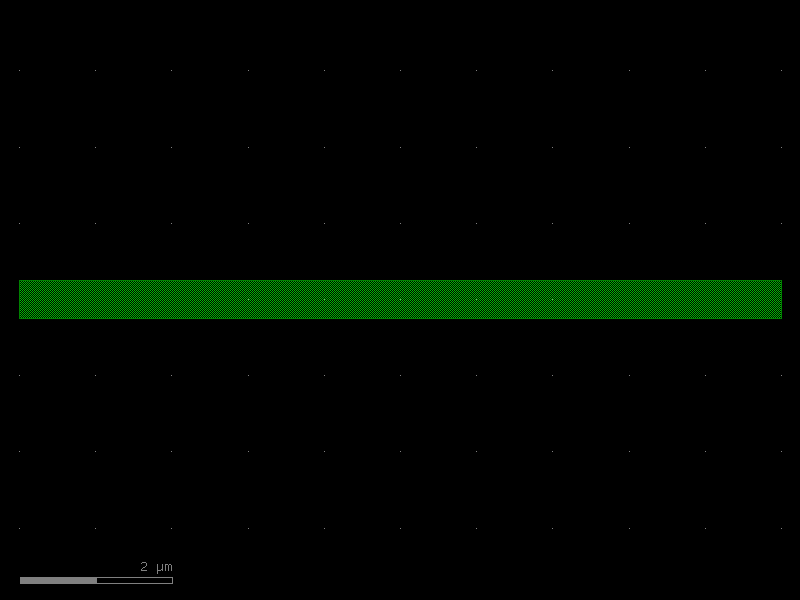

In [3]:
straight = straight_dbu_factory(pdk)

# Register a symmetric cross section (width in DBU) on the PDK, then build by name.
wg = pdk.get_icross_section(
    kf.CrossSectionSpecDict(
        layer=L.WG,
        width=pdk.to_dbu(0.5),  # 500 DBU = 0.5 µm
        unit="dbu",
        name="WG",
    )
)

wg_short = straight(cross_section="WG", length=pdk.to_dbu(10.0))  # 10 µm
wg_long = straight(cross_section="WG", length=pdk.to_dbu(20.0))

print("short name:", wg_short.name)
print("long  name:", wg_long.name)
print(
    "same object (same args)?",
    wg_short is straight(cross_section=wg, length=pdk.to_dbu(10.0)),
)
wg_short

## Cladding / exclude via the cross section

Extra layers (slab, exclude, cladding) are **sections** of the cross section —
`(layer, width)` or `(layer, min, max)` offsets around the core, in DBU.

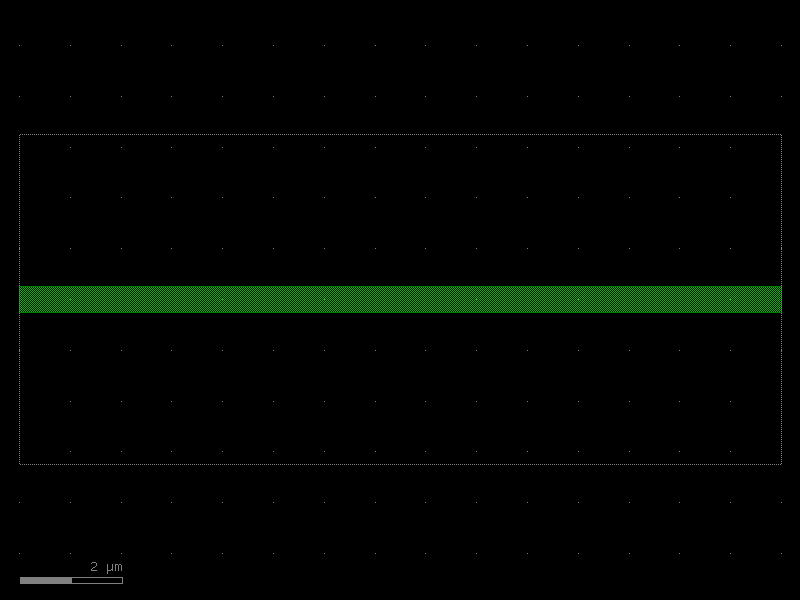

In [4]:
wg_clad_xs = pdk.get_icross_section(
    kf.CrossSectionSpecDict(
        layer=L.WG,
        width=pdk.to_dbu(0.5),
        sections=[(L.WGCLAD, pdk.to_dbu(3.0))],
        unit="dbu",
        name="WG_CLAD",
    )
)

wg_clad = straight(cross_section="WG_CLAD", length=pdk.to_dbu(15.0))
wg_clad

## See Also

| Topic | Where |
|-------|-------|
| Cross-sections (alternative spec) | [Cross-Sections](../../cross_sections.py) |